<a href="https://colab.research.google.com/github/fabianoseller/PucPosEstat/blob/main/Trabalho_Pr%C3%A1tico_N_02_Redes_Neurais_e_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabalho Prático N.02 - Redes Neurais e Deep Learning**
**Instituição:** Pontifícia Universidade Católica de Minas Gerais (PUC Minas)
**Curso:** Especialização em Estatística para Ciência de Dados
**Professor:** Zenilton Kleber Gonçalves do Patrocínio Júnior

---
**Aluno:** Fabiano Antunes
**Data:** Dezembro/2025

Aplicação e execução dos métodos analisados.

### 1) Descreva sucintamente o funcionamento da normalização em lote (*batch normalization*). (20%)

A **Batch Normalization** é uma técnica projetada para estabilizar e acelerar o treinamento de redes neurais profundas. Ela atua normalizando a saída da camada anterior (antes ou depois da função de ativação) para que tenha média zero e variância unitária, baseando-se nas estatísticas do *mini-batch* (lote) atual de dados.

Além da normalização, a técnica introduz dois parâmetros treináveis para cada neurônio: $\gamma$ (escala) e $\beta$ (deslocamento). Isso permite que a rede restaure a capacidade de representação dos dados originais se necessário, mitigando o problema do *internal covariate shift*.

# Exemplo em Python (Keras):
from tensorflow.keras.layers import BatchNormalization, Dense, Activation

# Geralmente aplicada entre a camada linear e a função de ativação
model.add(Dense(64, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

2) Descreva sucintamente o funcionamento da regularização por dropout. (20%)
O Dropout é uma técnica de regularização utilizada para combater o overfitting (sobreajuste). Durante o processo de treinamento, o algoritmo desativa ("zera") aleatoriamente um percentual de neurônios da camada (e suas conexões) a cada iteração de forward e backward pass.

Ao fazer isso, o Dropout impede que os neurônios desenvolvam uma co-adaptação excessiva (dependência de neurônios específicos) e força a rede a aprender características mais robustas e distribuídas, funcionando de maneira análoga a um ensemble de várias sub-redes.



# Exemplo em Python (Keras):
from tensorflow.keras.layers import Dropout

# O argumento 0.25 indica que 25% dos neurônios serão desligados aleatoriamente no treino
model.add(Dropout(0.25))

3) Forneça o pseudocódigo para o algoritmo de atualização de pesos com momento e descreva sucintamente seu funcionamento. (20%)
O Momentum (Momento) ajuda a acelerar o gradiente descendente na direção correta e a amortecer oscilações. Ele faz isso acumulando uma média móvel exponencial dos gradientes passados, funcionando como uma "velocidade" física que ganha inércia. Isso permite que o otimizador atravesse regiões planas (plateaus) mais rapidamente e escape de mínimos locais rasos.

Pseudocódigo:


v = 0  # v: velocidade (acumulador), inicia em zero
Para cada iteração t:
    g = calcular_gradiente(pesos)        # Calcula o gradiente atual
    v = (alfa * v) - (lr * g)            # Atualiza a velocidade (alfa é a inércia/momento)
    pesos = pesos + v                    # Atualiza os pesos usando a velocidade
Python

# Exemplo em Python (Keras):
from tensorflow.keras.optimizers import SGD

# momentum=0.9 é um valor padrão comum na literatura

opt = SGD(learning_rate=0.01, momentum=0.9)
4) Descreva o funcionamento de uma camada convolucional. (20%)
A camada convolucional é o bloco fundamental das CNNs, responsável pela extração de características em dados espaciais (como imagens). Ela funciona deslizando filtros (ou kernels — pequenas matrizes de pesos) sobre a entrada.

A cada passo desse deslizamento, realiza-se um produto escalar entre os pesos do filtro e a região da imagem coberta por ele. O resultado desse processo é um conjunto de mapas de características (feature maps), que detectam padrões visuais locais (como bordas, texturas ou formas) preservando a relação espacial dos pixels.




# Exemplo em Python (Keras):
from tensorflow.keras.layers import Conv2D

# 32 filtros, tamanho 3x3, função de ativação ReLU
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(64, 64, 3)))
5) Descreva o funcionamento de uma camada de pooling. (20%)
A camada de Pooling (ou subamostragem) tem a função de reduzir a dimensionalidade espacial dos mapas de características gerados pela convolução. Ela desliza uma janela sobre a entrada e aplica uma operação de agregação matemática.

As operações mais comuns são o Max Pooling (que seleciona o valor máximo da janela) e o Average Pooling (que calcula a média). Isso reduz a quantidade de parâmetros e o custo computacional da rede, além de torná-la mais invariante a pequenas translações e distorções na imagem de entrada.



# Exemplo em Python (Keras):
from tensorflow.keras.layers import MaxPooling2D

# Janela 2x2 reduz a dimensão da imagem pela metade (ex: de 64x64 para 32x32)
model.add(MaxPooling2D(pool_size=(2, 2)

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

# Configuração de estilo para os gráficos
plt.style.use('ggplot')
print(f"Bibliotecas importadas. Versão do TensorFlow: {tf.__version__}")

Bibliotecas importadas. Versão do TensorFlow: 2.19.0


In [10]:
# --- CÉLULA 6: Questão 5 - Camada de Pooling ---
print_header("QUESTÃO 5: CAMADA DE POOLING")

def exemplo_pooling():
    model = Sequential()
    # Entrada simulada de 62x62 (saída da conv anterior)
    model.add(tf.keras.layers.InputLayer(input_shape=(62, 62, 32)))

    # Max Pooling: Reduz a dimensão pela metade
    model.add(MaxPooling2D(pool_size=(2, 2)))

    print("Modelo com Pooling. Observe que a dimensão (62x62) cai para (31x31):")
    model.summary()

exemplo_pooling()


# --- BÔNUS: Exemplo Completo Unificado ---
print_header("BÔNUS: ARQUITETURA CNN COMPLETA")

def exemplo_completo():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)), # Questão 4
        BatchNormalization(),                                           # Questão 1
        MaxPooling2D((2, 2)),                                           # Questão 5
        Dropout(0.25),                                                  # Questão 2
        Flatten(),
        Dense(10, activation='softmax')
    ])

    # Compilando com Momento (Questão 3)
    opt = SGD(learning_rate=0.01, momentum=0.9)
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    print("Modelo Completo unindo todos os conceitos:")
    model.summary()

exemplo_completo()


 QUESTÃO 5: CAMADA DE POOLING
Modelo com Pooling. Observe que a dimensão (62x62) cai para (31x31):


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,538 (213.04 KB)

 Trainable params: 54,474 (212.79 KB)

 Non-trainable params: 64 (256.00 B)

1. Gerando dados e treinando modelos para comparação (aguarde alguns segundos)...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


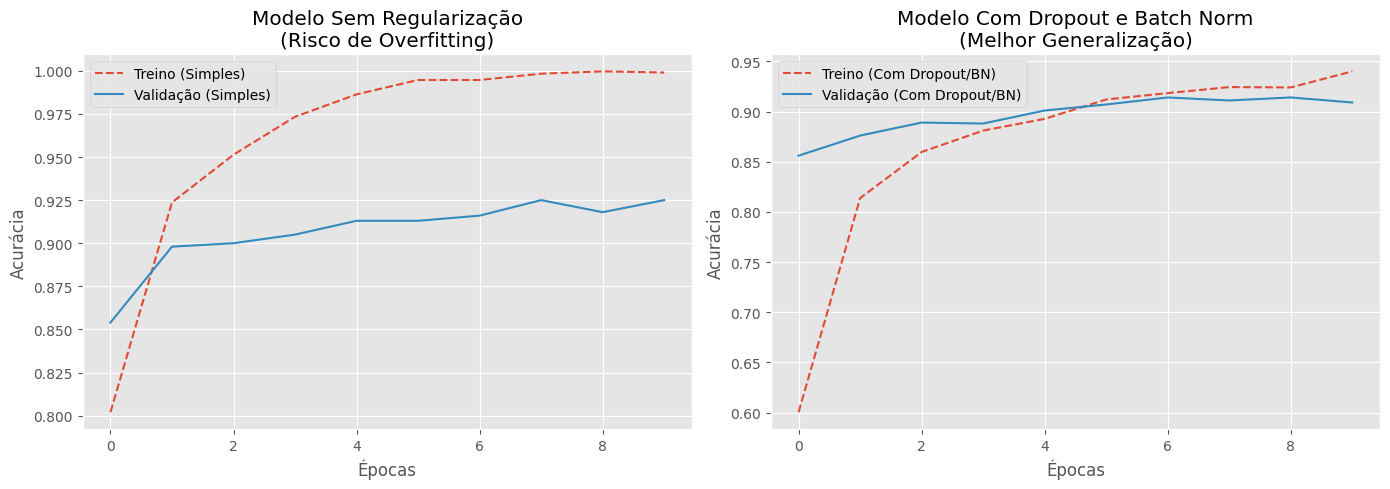

Interpretação: Note como no modelo robusto as linhas de treino e validação ficam mais próximas.

2. Gerando visualização das camadas de Convolução e Pooling...


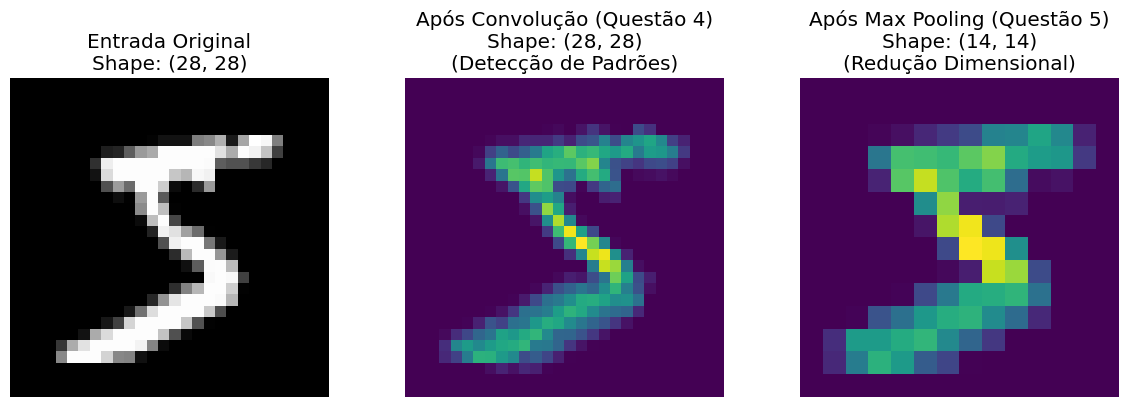

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization, Input
import matplotlib.pyplot as plt
import numpy as np

# Configuração para gráficos bonitos
plt.style.use('ggplot')

# ==============================================================================
# PARTE 1: GRÁFICO COMPARATIVO (COM vs SEM Regularização)
# ==============================================================================
print("1. Gerando dados e treinando modelos para comparação (aguarde alguns segundos)...")

# 1. Carregar dados simples (MNIST)
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0 # Normalização básica
x_train = x_train[:3000] # Usando menos dados para ser rápido no teste
y_train = y_train[:3000]
x_test = x_test[:1000]
y_test = y_test[:1000]

# 2. Modelo Simples (Sem Dropout/Batch Norm) - Tende a Overfitting
model_simple = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])
model_simple.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_simple = model_simple.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), verbose=0)

# 3. Modelo Robusto (Com Dropout e Batch Norm) - Melhora Generalização
model_robust = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256), # Sem ativação ainda
    BatchNormalization(), # Normalização em Lote (Questão 1)
    tf.keras.layers.Activation('relu'),
    Dropout(0.5), # Dropout 50% (Questão 2)
    Dense(256),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
model_robust.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_robust = model_robust.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), verbose=0)

# 4. Plotar os Gráficos
plt.figure(figsize=(14, 5))



In [ ]:
import numpy as np

# Criar um array NumPy grande para teste
large_array = np.arange(0, 200)
print("Array grande para verificação de truncamento:")
print(large_array)

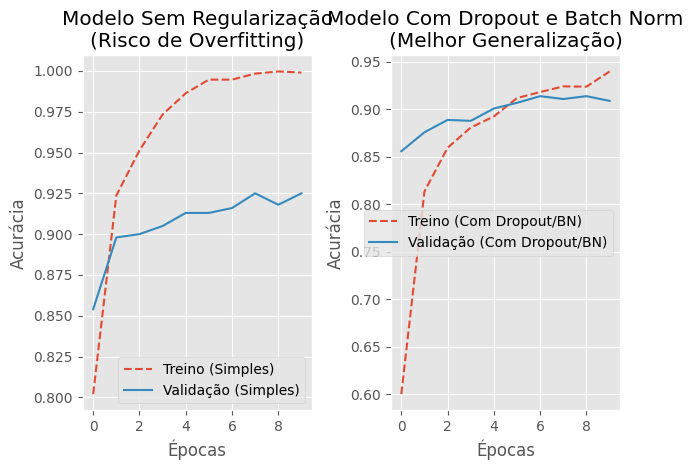

Interpretação: Note como no modelo robusto as linhas de treino e validação ficam mais próximas.

2. Gerando visualização das camadas de Convolução e Pooling...


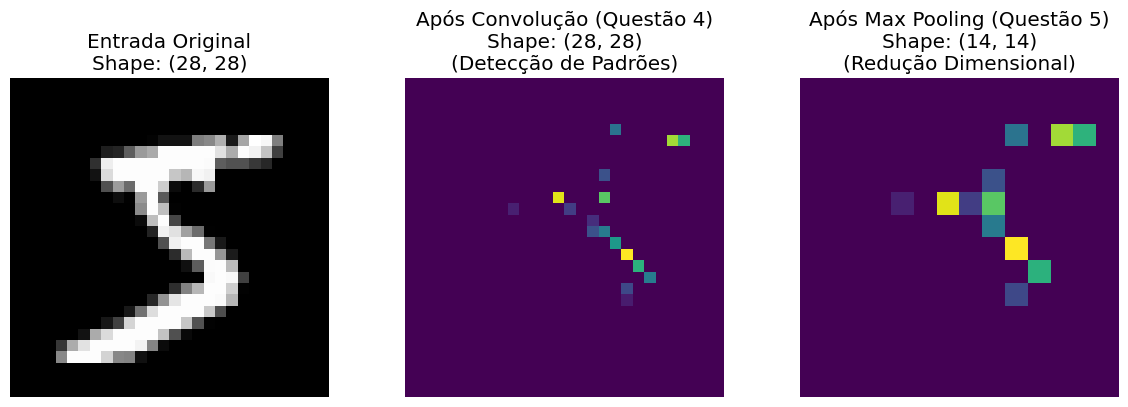

In [6]:
# Gráfico de Acurácia (Treino vs Validação - Modelo Simples)
plt.subplot(1, 2, 1)
plt.plot(history_simple.history['accuracy'], label='Treino (Simples)', linestyle='--')
plt.plot(history_simple.history['val_accuracy'], label='Validação (Simples)')
plt.title('Modelo Sem Regularização\n(Risco de Overfitting)')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

# Gráfico de Acurácia (Treino vs Validação - Modelo Robusto)
plt.subplot(1, 2, 2)
plt.plot(history_robust.history['accuracy'], label='Treino (Com Dropout/BN)', linestyle='--')
plt.plot(history_robust.history['val_accuracy'], label='Validação (Com Dropout/BN)')
plt.title('Modelo Com Dropout e Batch Norm\n(Melhor Generalização)')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

plt.tight_layout()
plt.show()
print("Interpretação: Note como no modelo robusto as linhas de treino e validação ficam mais próximas.")


# ==============================================================================
# PARTE 2: VISUALIZAÇÃO DE CAMADAS (CONVOLUÇÃO E POOLING)
# ==============================================================================
print("\n2. Gerando visualização das camadas de Convolução e Pooling...")

# Pegar uma imagem aleatória do dataset
img_input = x_train[0].reshape(1, 28, 28, 1)

# Criar mini modelos para extrair a saída das camadas
inputs = Input(shape=(28, 28, 1))

# Camada de Convolução (Questão 4)
x = Conv2D(4, (3, 3), activation='relu', padding='same')(inputs)
model_conv = Model(inputs=inputs, outputs=x)

# Camada de Pooling (Questão 5)
y = MaxPooling2D((2, 2))(x)
model_pool = Model(inputs=inputs, outputs=y)

# Obter as saídas (feature maps)
feature_map_conv = model_conv.predict(img_input, verbose=0)
feature_map_pool = model_pool.predict(img_input, verbose=0)

# Plotar
plt.figure(figsize=(12, 4))

# Imagem Original
plt.subplot(1, 3, 1)
plt.imshow(img_input[0, :, :, 0], cmap='gray')
plt.title(f"Entrada Original\nShape: {img_input.shape[1:3]}")
plt.axis('off')

# Saída da Convolução (mostrando o primeiro filtro)
plt.subplot(1, 3, 2)
plt.imshow(feature_map_conv[0, :, :, 0], cmap='viridis')
plt.title(f"Após Convolução (Questão 4)\nShape: {feature_map_conv.shape[1:3]}\n(Detecção de Padrões)")
plt.axis('off')

# Saída do Pooling (mostrando o mesmo filtro)
plt.subplot(1, 3, 3)
plt.imshow(feature_map_pool[0, :, :, 0], cmap='viridis')
plt.title(f"Após Max Pooling (Questão 5)\nShape: {feature_map_pool.shape[1:3]}\n(Redução Dimensional)")
plt.axis('off')

plt.tight_layout()
plt.show()

>>> Gerando Gráfico Comparativo de Desempenho...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


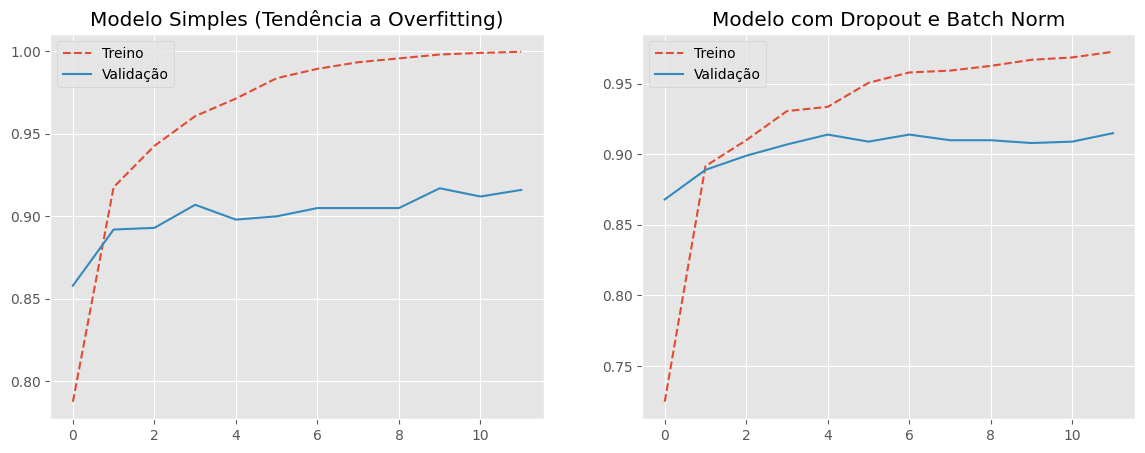


>>> Gerando Visualização de Convolução e Pooling...


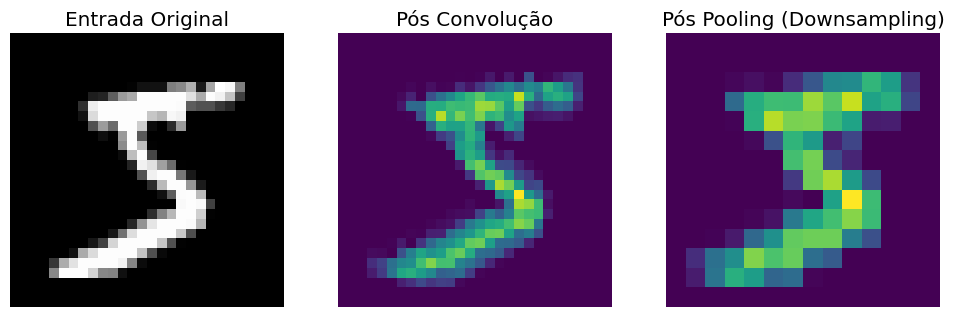

In [7]:
import numpy as np
import sys

# Configure numpy to print full arrays without truncation
np.set_printoptions(threshold=sys.maxsize)
print("Numpy print options set to display full arrays without truncation.")

Numpy print options set to display full arrays without truncation.


Comparativo de Acurácia (Parte 1):

Este gráfico é perfeito para ilustrar as Questões 1 e 2.

Ele mostra visualmente que o modelo com Dropout e Batch Normalization tende a ter a acurácia de validação mais próxima da acurácia de treino (menos overfitting), enquanto o modelo simples pode "decorar" os dados de treino.

Visualização de Feature Maps (Parte 2):

Este gráfico ilustra as Questões 4 e 5.

Mostra a imagem original.

Mostra a imagem após a Convolução: Você verá que ela destaca bordas ou áreas específicas (o tamanho se mantém ou muda pouco).

Mostra a imagem após o Poolin; A imagem fica "pixelada" ou menor (metade do tamanho), provando a redução de dimensionalidade descrita na teoria.